In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

np.random.seed(42)
np.deterministic = True

## 数据集的读取

In [2]:
pulsar = pd.read_csv("../data/pulsar.csv")

In [3]:
# Note that there are many NaNs in the dataset, that's why 
row_nan_count = pulsar.isna().any(axis=1).to_numpy().sum()
print(f"Proportion of rows with NaN: {row_nan_count / pulsar.shape[0]:.2%}")

col_nan = pulsar.isna().any(axis=0)
col_nan

Proportion of rows with NaN: 25.98%


 Mean of the integrated profile                  False
 Standard deviation of the integrated profile    False
 Excess kurtosis of the integrated profile        True
 Skewness of the integrated profile              False
 Mean of the DM-SNR curve                        False
 Standard deviation of the DM-SNR curve           True
 Excess kurtosis of the DM-SNR curve             False
 Skewness of the DM-SNR curve                     True
target_class                                     False
dtype: bool

## 数据集的可视化

### 数据分布直方图

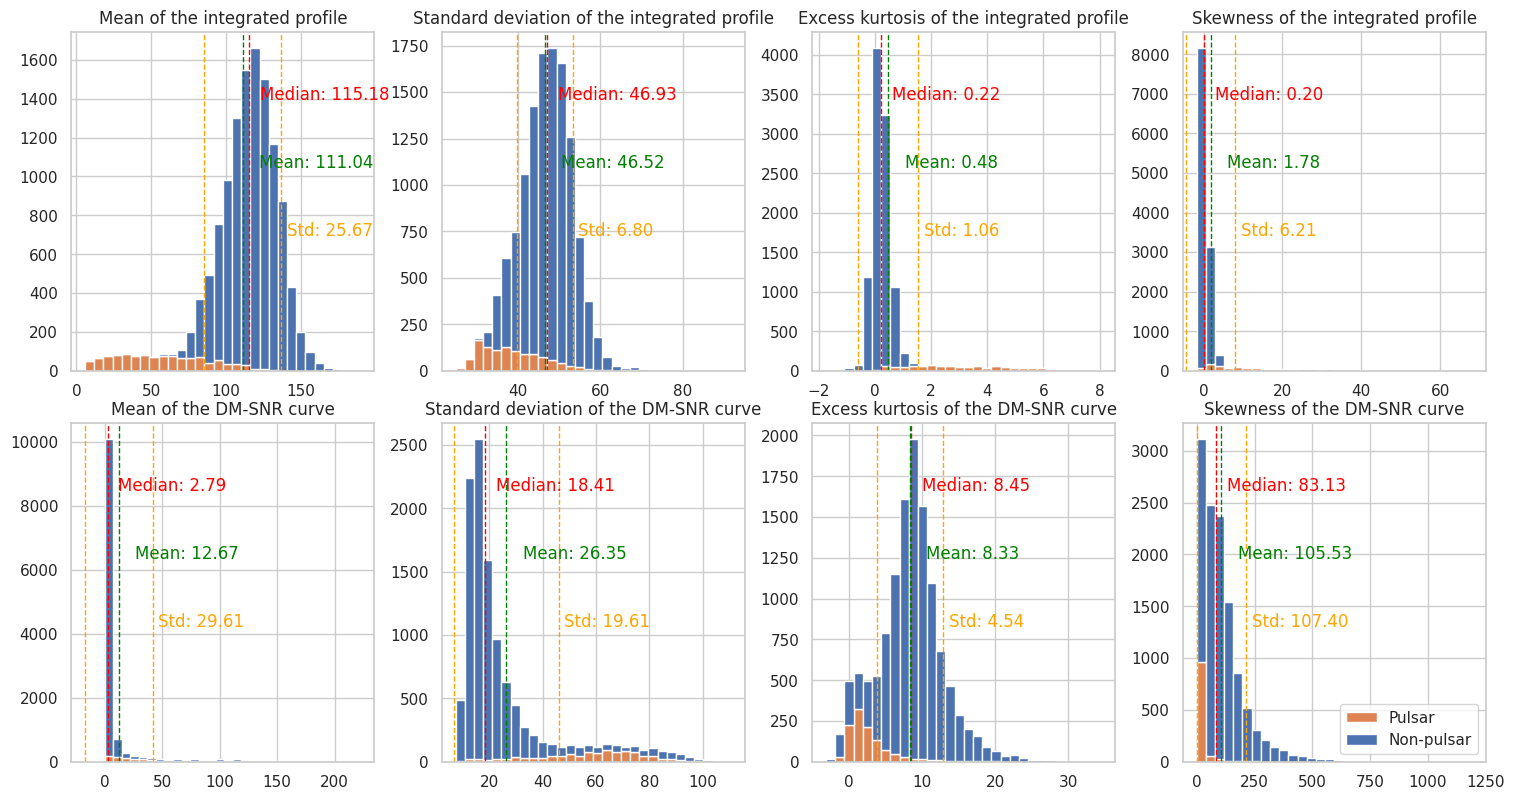

In [4]:
plt.subplots(2, 4, figsize=(15, 8))
plt.tight_layout()

for i, col in enumerate(pulsar.columns[:-1]):
    X, y = pulsar[col], pulsar['target_class']
    X = X.dropna()
    y = y[X.index]

    plt.subplot(2, 4, i + 1)
    plt.hist(
        [
            X.to_numpy()[y == 1],
            X.to_numpy()[y == 0],
        ],
        histtype='barstacked',
        color=['C1', 'C0'],
        bins=30,
        label=['Pulsar', 'Non-pulsar'],
    )
    plt.title(col[1:])

    median = pulsar[col].median()
    plt.axvline(median, color='red', linestyle='dashed', linewidth=1)
    plt.text(median + 0.04 * (pulsar[col].max() - pulsar[col].min()), 
             plt.ylim()[1] * 0.8, 
             f'Median: {median:.2f}', color='red')
    
    mean = pulsar[col].mean()
    plt.axvline(mean, color='green', linestyle='dashed', linewidth=1)
    plt.text(mean + 0.06 * (pulsar[col].max() - pulsar[col].min()), 
             plt.ylim()[1] * 0.6, 
             f'Mean: {mean:.2f}', color='green')
    
    std = pulsar[col].std()
    plt.axvline(mean + std, color='orange', linestyle='dashed', linewidth=1)
    plt.axvline(mean - std, color='orange', linestyle='dashed', linewidth=1)
    plt.text(mean + std + 0.02 * (pulsar[col].max() - pulsar[col].min()), 
             plt.ylim()[1] * 0.4, 
             f'Std: {std:.2f}', color='orange')

plt.legend()
plt.savefig('../../assets/feature_distributions.pdf', bbox_inches='tight')

### 相关性矩阵

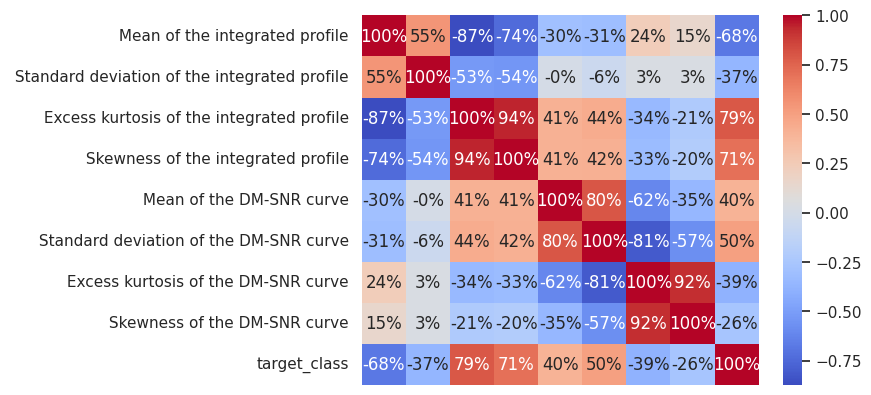

In [5]:
sns.heatmap(
    pulsar.corr(),
    annot=True,
    fmt=".0%",
    xticklabels=['']*8,
    yticklabels=pulsar.columns,
    cmap='coolwarm')
plt.savefig('../../assets/correlation_heatmap.pdf', bbox_inches='tight')

### PCA 降维

[[-0.359445   -0.21811666  0.41683396  0.40074213  0.34600677  0.38525995
  -0.36888053 -0.29096538]
 [ 0.36150176  0.42734906 -0.31599837 -0.30443298  0.24478535  0.31742432
  -0.41435464 -0.40222757]]


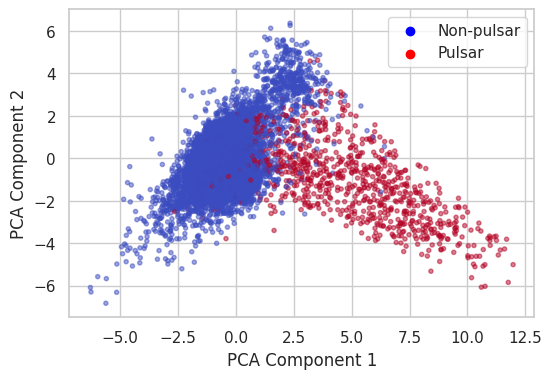

In [6]:
from feature_engineering import PCAProjector

pca = PCAProjector(n_components=2)

X_nonan = pulsar.drop(columns=['target_class']).dropna()
X_nonan = (X_nonan - X_nonan.mean()) / X_nonan.std()
X_pca = pca.fit_transform(X_nonan)
y_pca = pulsar['target_class'].loc[X_nonan.index]

plt.figure(figsize=(6, 4))
plt.set_cmap('coolwarm')
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y_pca,
    alpha=0.5,
    cmap='coolwarm',
    marker='.',
)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')

plt.scatter([], [], c='blue', label='Non-pulsar')
plt.scatter([], [], c='red', label='Pulsar')
plt.legend()

plt.savefig('../../assets/pca_scatter.pdf', bbox_inches='tight')
print(pca.pca.components_)

## 线性模型的可视化

为了使可视化效果更为明显，这次我们选择原始训练数据的一个子集；这样，决策边界发生的微小变化就会得到更直观的呈现。

在读入输入的时候，我们同时将其标准化处理。

In [7]:
from ucimlrepo import fetch_ucirepo 
# fetch dataset 
htru2 = fetch_ucirepo(id=372) 
  
# data (as pandas dataframes) 
X = htru2.data.features 
y = htru2.data.targets 
  
# metadata 
print(htru2.metadata) 
  
# variable information 
print(htru2.variables) 

{'uci_id': 372, 'name': 'HTRU2', 'repository_url': 'https://archive.ics.uci.edu/dataset/372/htru2', 'data_url': 'https://archive.ics.uci.edu/static/public/372/data.csv', 'abstract': 'Pulsar candidates collected during the HTRU survey. Pulsars are a type of star, of considerable scientific interest. Candidates must be classified in to pulsar and non-pulsar classes to aid discovery.', 'area': 'Physics and Chemistry', 'tasks': ['Classification', 'Clustering'], 'characteristics': ['Multivariate'], 'num_instances': 17898, 'num_features': 8, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2015, 'last_updated': 'Wed Apr 03 2024', 'dataset_doi': '10.24432/C5DK6R', 'creators': ['Robert Lyon'], 'intro_paper': {'ID': 460, 'type': 'NATIVE', 'title': 'Fifty years of pulsar candidate selection: from simple filters to a new principled real-time classification approach', 'a

In [8]:
from feature_engineering import PCAProjector
pca = PCAProjector(n_components=2)

sample_ids = np.random.choice(X.shape[0], size=500, replace=False)
X_sample = X.iloc[sample_ids].to_numpy()
y_sample = y.iloc[sample_ids].to_numpy().ravel()
X_mean, X_std = X.mean().to_numpy(), X.std().to_numpy()
X = (X - X_mean) / X_std
X_sample = (X_sample - X_mean) / X_std
pca.fit(X.to_numpy())

In [9]:
def plot_decision_boundary_2D(model, X, y, method_name):
    """
    将高维数据 PCA 到 2D，再可视化 SVM 决策边界。
    假设 X 已经过标准化处理。
    """
    X_2d = pca.transform(X)

    # 创建网格用于绘图
    x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
    y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    # 网格点逆 PCA 回高维
    grid_2d = np.c_[xx.ravel(), yy.ravel()]
    grid_hd = pca.inverse_transform(grid_2d)

    Z = model.predict(grid_hd)
    Z = Z.reshape(xx.shape)

    # 绘制结果 (不创建新图，直接画在当前子图)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")

    # 画出非支持向量
    non_support = np.setdiff1d(np.arange(X_2d.shape[0]), model.support_)
    plt.scatter(
        X_2d[non_support, 0], 
        X_2d[non_support, 1],
        c=y[non_support],
        marker='x',
        alpha=0.5,
        cmap="coolwarm",
    )
    
    # 画出支持向量
    support_vectors_2d = X_2d[model.support_]
    plt.scatter(
        support_vectors_2d[:, 0], support_vectors_2d[:, 1],
        # s=40, linewidth=1.5, facecolors='none', edgecolors='yellow',
        # marker='^', c=["magenta" if y[i] == 1 else 'cyan' for i in model.support_],
        marker='^', c=y[model.support_],
        label='Support Vectors'
    )

    # 画出 margin 边界
    if hasattr(model, "decision_function"):
        Z_margin = model.decision_function(grid_hd)
        Z_margin = Z_margin.reshape(xx.shape)
        plt.contour(
            xx, yy, Z_margin,
            levels=[-1, 1],
            colors='k',
            linestyles='dashed',
            linewidths=1
        )
        # 计算 F1 score
        y_pred = model.predict(X)
        from sklearn.metrics import f1_score
        f1_score = f1_score(y, y_pred)

        if hasattr(model, "coef_"):
            plt.text(
                0.50, 0.95,
                f"Margin width: {1 / np.sqrt(np.sum(model.coef_ ** 2)):.2f}\n"
                # model.score is not F1 score, need to compute manually if needed
                f"F1 score: {f1_score:.2f}",
                transform=plt.gca().transAxes,
                verticalalignment='top'
            )
        
        else:
            plt.text(
                0.50, 0.95,
                f"F1 score: {f1_score:.2f}",
                transform=plt.gca().transAxes,
                verticalalignment='top'
            )
    
    plt.title(f"{method_name}")
    # plt.xlabel("PCA Component 1")
    # plt.ylabel("PCA Component 2")

C=1e-02, #SV=59, acc=0.972, time=0.002s
C=5e+00, #SV=26, acc=0.986, time=0.003s
C=2e+03, #SV=23, acc=0.988, time=0.078s
C=1e+06, #SV=23, acc=0.986, time=29.589s
degree=1, #SV=30, acc=0.982, time=0.002s
degree=2, #SV=35, acc=0.980, time=0.002s
degree=3, #SV=32, acc=0.988, time=0.002s
degree=4, #SV=35, acc=0.984, time=0.003s
gamma=scale, #SV=55, acc=0.992, time=0.003s
gamma=1, #SV=151, acc=0.996, time=0.004s
gamma=0.1, #SV=52, acc=0.990, time=0.003s
gamma=0.01, #SV=39, acc=0.976, time=0.003s


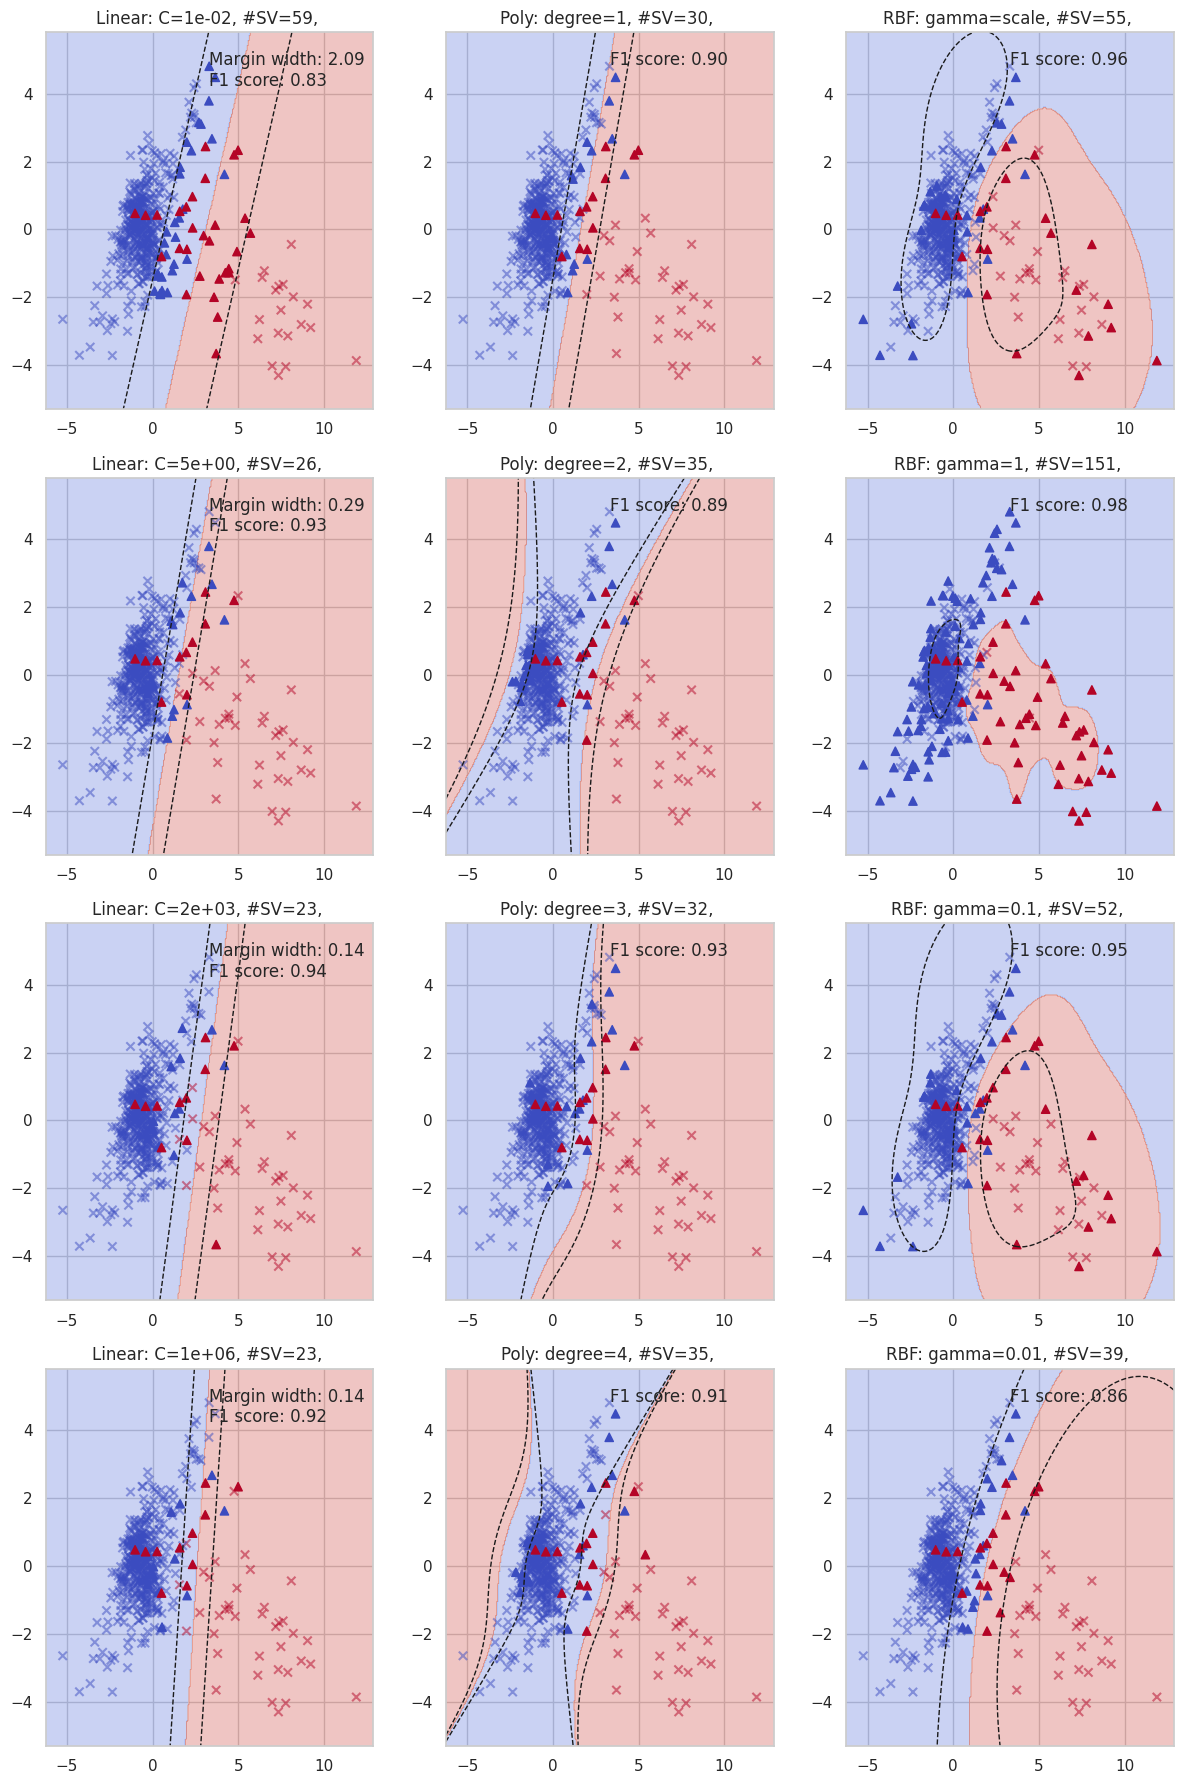

In [ ]:
from sklearn.svm import SVC
import time

plt.subplots(4, 3, figsize=(12, 18))

# =================================================
# PART 1: Linear Kernel SVM with varying C
# =================================================

C_s = np.logspace(-2, 6, 4)

for i, C in enumerate(C_s):
    svc = SVC(kernel='linear', C=C)
    t1 = time.time()
    svc.fit(X_sample, y_sample)
    t2 = time.time()
    print(f"C={C:1.0e}, #SV={sum(svc.n_support_)}, acc={svc.score(X_sample, y_sample):.3f}, time={t2 - t1:.3f}s")

    # plot decision boundary
    plt.subplot(4, 3, 3 * i + 1)
    # 这个函数与 visualization.py 中的极其类似，但是只在一个
    # 子图上绘制，不保存文件
    plot_decision_boundary_2D(svc, X_sample, y_sample, f"Linear: C={C:1.0e}, "
                              f"#SV={sum(svc.n_support_)}, ")

# =================================================
# PART 2: Polynomial Kernel SVM with varying degree
# =================================================

C = 5
degs = [1, 2, 3, 4]

for i, deg in enumerate(degs):
    svc = SVC(kernel='poly', degree=deg, C=C)
    t1 = time.time()
    svc.fit(X_sample, y_sample)
    t2 = time.time()
    print(f"degree={deg}, #SV={sum(svc.n_support_)}, acc={svc.score(X_sample, y_sample):.3f}, time={t2 - t1:.3f}s")
    # plot decision boundary
    plt.subplot(4, 3, 3 * i + 2)
    # 这个函数与 visualization.py 中的极其类似，但是只在一个
    # 子图上绘制，不保存文件
    plot_decision_boundary_2D(svc, X_sample, y_sample, f"Poly: degree={deg}, "
                              f"#SV={sum(svc.n_support_)}, ")

# =================================================
# PART 3: RBF Kernel SVM with varying gamma
# =================================================

C = 5
gamma = ['scale', 1, 0.1, 0.01]


for i, g in enumerate(gamma):
    svc = SVC(kernel='rbf', gamma=g, C=C)
    t1 = time.time()
    svc.fit(X_sample, y_sample)
    t2 = time.time()
    print(f"gamma={g}, #SV={sum(svc.n_support_)}, acc={svc.score(X_sample, y_sample):.3f}, time={t2 - t1:.3f}s")
    # plot decision boundary
    plt.subplot(4, 3, 3 * i + 3)
    # 这个函数与 visualization.py 中的极其类似，但是只在一个
    # 子图上绘制，不保存文件
    plot_decision_boundary_2D(svc, X_sample, y_sample, f"RBF: gamma={g}, "
                              f"#SV={sum(svc.n_support_)}, ")

plt.tight_layout()
plt.savefig('../../assets/svm_all_kernel_decision_boundaries.pdf', bbox_inches='tight')

## 超参数调优可视化